In [ ]:
# ==============================================================================
# TAHAP 1: NORMALISASI TEKS
# Tugas: Mengubah kata-kata tidak baku (slang, singkatan) menjadi kata baku
#        berdasarkan kamus yang sudah dibuat.
# ==============================================================================

# 1. IMPORT LIBRARY
import pandas as pd
import re
import time
import sys

# ==============================================================================
# 2. KAMUS NORMALISASI (ASET ANDA YANG PALING BERHARGA)
# ==============================================================================
REPLACEMENTS_DICT = {
    # --- Singkatan Umum & Typo ---
    'yg': 'yang', 'ga': 'tidak', 'gak': 'tidak', 'gk': 'tidak', 'enggak': 'tidak', 'nggak': 'tidak', 'ndak': 'tidak', 'ndk': 'tidak', 'gaada': 'tidak ada',
    'tdk': 'tidak', 'bkn': 'bukan', 'utk': 'untuk', 'dgn': 'dengan', 'krn': 'karena', 'karna': 'karena',
    'bgt': 'banget', 'jg': 'juga', 'aja': 'saja', 'jd': 'jadi', 'jgn': 'jangan', 'aza': 'saja',
    'klo': 'kalau', 'kalo': 'kalau', 'kl': 'kalau', 'knp': 'kenapa', 'gmn': 'bagaimana', 'gimana': 'bagaimana', 'bgmn': 'bagaimana', 'ginana': 'bagaimana',
    'sdh': 'sudah', 'udh': 'sudah', 'blm': 'belum', 'balum': 'belum', 'sblm': 'sebelum', 'blom': 'belum',
    'skrg': 'sekarang', 'skrng': 'sekarang', 'bbrp': 'beberapa', 'brp': 'berapa', 'byk': 'banyak', 'bnyk': 'banyak',
    'tp': 'tapi', 'tpi': 'tapi', 'pdhl': 'padahal',
    'trus': 'terus', 'trs': 'terus', 'bngt': 'banget', 'dpt': 'dapat', 'dr': 'dari',
    'kpd': 'kepada', 'kyk': 'seperti', 'ky': 'seperti', 'nih': 'ini', 'sih': 'sih', 'tuh': 'itu', 'ni': 'ini',
    'dong': 'dong', 'kok': 'kok', 'pake': 'pakai', 'dipake': 'dipakai', 'dipke': 'dipakai', 'dipakeitx': 'dipakai',
    'sm': 'sama', 'ama': 'sama', 'cmn': 'cuma',
    'kpn': 'kapan', 'tlg': 'tolong', 'tlong': 'tolong', 'mnt': 'minta', 'gpp': 'tidak apa-apa', 'donk': 'dong',
    'emg': 'memang', 'sbnrnya': 'sebenarnya', 'tq': 'terima kasih', 'yth': 'yang terhormat', 'sgt': 'sangat', 'stlh': 'setelah',
    'lbih': 'lebih', 'bner': 'benar', 'sgera': 'segera', 'slm': 'salam',
    'itx': 'itu', 'bknnya': 'bukannya', 'tmbh': 'tambah', 'mlh': 'malah',
    'pas': 'saat', 'kmrin': 'kemarin', 'i': 'ini', 'liat': 'lihat', 'libat': 'lihat',
    'masiah': 'masih', 'hancur': 'hancur', 'ancur': 'hancur', 'boro boro': 'boro-boro', 'boro2': 'boro-boro', 'gajelas': 'tidak jelas',
    'notif': 'notifikasi', 'didaftarin': 'didaftarkan', 'bwat': 'buat', 'komen': 'komentar', 'ngabisin': 'menghabiskan',
    'mala': 'malah', 'bredel': 'rusak', 'disaat': 'disaat', 'genting': 'genting', 'masukin': 'memasukkan', 'kocak': '[tertawa]',
    'bikin': 'membuat', 'muak': 'muak', 'sia': 'sia-sia', 'bosen': 'bosan',
    'aku': 'saya', 'aq': 'saya', 'gw': 'saya', 'gua': 'saya', 'gue': 'saya', 'w': 'saya', 'sy': 'saya', 'sya': 'saya',
    'kamu': 'kamu', 'lo': 'kamu', 'loe': 'kamu', 'lu': 'kamu', 'org': 'orang', 'kau': 'kamu',
    'x': 'kali', 'pe x': 'berkali kali', 'y': 'ya', 'maww': 'mau', 'mw': 'mau', 'af': 'maaf', 'maap': 'maaf', 'maunya': 'maunya',
    'wkwk': '[tertawa]', 'wkwkwk': '[tertawa]', 'hahaha': '[tertawa]', 'hehe': '[tertawa]', 'xixi': '[tertawa]',
    'hiks': '[sedih]', 'huhu': '[sedih]',
    'astaga': 'astaga', 'astaghfirullah': 'astaga', 'naudzubillah': 'naudzubillah',
    'anjim': '[umpatan]', 'anjir': '[umpatan]', 'anjay': 'umpatan', 'njir': '[umpatan]', 'jir': '[umpatan]',
    'opo': 'apa', 'iki': 'ini', 'iku': 'itu', 'kui': 'itu', 'piye': 'bagaimana', 'kepiye': 'bagaimana',
    'angel': 'sulit', 'abot': 'berat', 'rudet': 'rumit', 'suwe': 'lama', 'suwi': 'lama', 'seabad': 'lama sekali', 'lila': 'lama',
    'meneh': 'lagi', 'wae': 'saja', 'ae': 'saja', 'jan': 'sungguh', 'tenan': 'benar', 'tenan': 'sungguh',
    'ora': 'tidak', 'ra': 'tidak', 'raiso': 'tidak bisa', 'oraiso': 'tidak bisa', 'g bisa': 'tidak bisa', 'gak bisa': 'tidak bisa', 'gabisa': 'tidak bisa',
    'kabeh': 'semua', 'mbuh': 'tidak tahu', 'mumet': 'pusing', 'nang': 'di', 'neng': 'di',
    'jancok': '[umpatan]', 'matamu': '[umpatan]', 'cok': '[umpatan]', 'cuk': '[umpatan]', 'nanaon': 'apa-apaan', 'hese': 'sulit', 'kie': 'begini', 'ge': 'juga',
    'opo o': 'apa apa', 'wes': 'sudah', 'isoh': 'bisa', 'iso': 'bisa', 'bsa': 'bisa', 'bari jeung': 'tetapi', 'teu': 'tidak', 'cobaen': 'coba',
    'monggo': 'silakan', 'monggo': 'silakan', 'matur nuwun': 'terima kasih', 'suwun': 'terima kasih', 'asline': 'aslinya', 'nggwe': 'buat',
    'disek': 'dulu', 'sakdurunge': 'sebelumnya', 'bukaen': 'buka', 'koyok': 'seperti',
    'dongo': 'bodoh', 'dungu': 'bodoh', 'bego': 'bodoh', 'goblok': 'bodoh', 'gblk': 'bodoh', 'tolol': 'bodoh', 'tlol': 'tolol', 'dongok': 'bodoh',
    'anjing': '[umpatan]', 'anjiing': '[umpatan]', 'asu': '[umpatan]', 'hancok': '[umpatan]', 'anjeng': '[umpatan]',
    'bangsat': '[umpatan]', 'bgst': '[umpatan]', 'biadab': 'biadab',
    'kontol': '[umpatan]', 'memek': '[umpatan]', 'jembut': '[umpatan]', 'kntl': '[umpatan]',
    'tai': 'kotoran', 'taik': 'kotoran', 'taek': 'kotoran', 'kampret': '[umpatan]', 'sial': 'sialan', 'najis': '[umpatan]',
    'babi': '[umpatan]', 'binatang': '[umpatan]', 'bajingan': '[umpatan]', 'sampah': '[sampah]', 'bobrok': 'bobrok', 'kotoran': '[kotoran]', 'buwosok': 'busuk', 'bosok': 'busuk',
    'ngehek': '[umpatan]', 'entut': 'kentut', 'mungak': 'muak',
    'apk': 'aplikasi', 'app': 'aplikasi', 'apps': 'aplikasi', 'apliksi': 'aplikasi', 'uplikasinya': 'aplikasinya', 'aplikasinya': 'aplikasinya',
    'eror': 'error', 'erorr': 'error', 'erorrr': 'error', 'ngebug': 'bug',
    'lemot': 'lambat', 'lelet': 'lambat', 'loding': 'loading',
    'update': 'pembaruan', 'updet': 'pembaruan', 'diupdate': 'diperbarui', 'pembaruan': 'pembaruan', 'diperbaharui': 'diperbarui', 'abdet': 'pembaruan',
    'login': 'masuk', 'log in': 'masuk', 'logout': 'keluar', 'log out': 'keluar', 'msuk': 'masuk',
    'register': 'daftar', 'registrasi': 'pendaftaran', 'daptar': 'daftar', 'pndftran': 'pendaftaran', 'didaptar': 'didaftar', 'daftarin': 'daftarkan',
    'verif': 'verifikasi', 'ferivikasi': 'verifikasi', 'perivikasi': 'verifikasi', 'verifikasi': 'verifikasi', 'verivikasi': 'verifikasi', 'blel': 'gagal', 'captcha': 'captcha', 'captca': 'captcha',
    'faskes': 'fasilitas kesehatan', 'faskesnya': 'fasilitas kesehatannya',
    'bpjs': 'bpjs', 'jkn': 'jkn', 'kesehatan': 'kesehatan', 'pasien': 'pasien',
    'cs': 'customer service', 'admin': 'admin', 'operator': 'operator',
    'kartu digital': 'kartu digital', 'kartu fisik': 'kartu fisik', 'kk': 'kartu keluarga', 'ktp': 'kartu tanda penduduk', 'kluarga': 'keluarga',
    'tagihan': 'tagihan', 'iuran': 'iuran', 'premi': 'premi',
    'no hp': 'nomor ponsel', 'nomor hp': 'nomor ponsel', 'no peserta': 'nomor peserta', 'nomer': 'nomor',
    'password': 'password', 'pasword': 'password', 'pssword': 'password', 'asword': 'password',
    'cesar': 'sesar', 'operasi': 'operasi', 'autodebit': 'autodebit', 'nik': 'nik',
    'diklik': 'diklik', 'diklik': 'diklik', 'muncul': 'muncul', 'nungguan': 'menunggu', 'oflline': 'offline', 'offline': 'offline',
    'bulak balek': 'bolak-balik', 'bulak bali': 'bolak-balik',
    'bagusss': 'bagus', 'baguss': 'bagus', 'bgs': 'bagus', 'good': 'bagus', 'gud': 'bagus',
    'jelek': 'jelek', 'jlek': 'jelek', 'jellek': 'jelek', 'jelex': 'jelek', 'bapuk': 'jelek',
    'susah': 'sulit', 'ribet': 'rumit', 'gampang': 'mudah',
    'mantap': 'mantap', 'mntp': 'mantap', 'mantul': 'mantap betul',
    'ok': 'oke', 'okeey': 'oke',
    'makasih': 'terima kasih', 'mksh': 'terima kasih', 'thx': 'terima kasih', 'terimakasih': 'terima kasih',
    'tolongg': 'tolong', 'plis': 'tolong', 'pls': 'tolong',
    'respon': 'respons', 'responnya': 'responsnya',
    'bangettt': 'banget', 'bangett': 'banget', 'bgtt': 'banget',
    'parah': 'parah', 'males': 'malas', 'mager': 'malas gerak',
    'kecewa': 'kecewa', 'kcewa': 'kecewa',
    'bintang': 'bintang', 'bntg': 'bintang', 'nol': 'nol',
    'fungsi': 'fungsi', 'fungsik': 'fungsi', 'guna': 'guna',
    'nyampe': 'sampai', 'sampe': 'sampai', 'dikirim': 'dikirim', 'balesan': 'balasan',
    'jt': 'juta', 'rb': 'ribu', 'th': 'tahun', 'bln': 'bulan', 'wktu': 'waktu', 'ttap': 'tetap',
    'ketrangannya': 'keterangannya', 'pnjelasanya': 'penjelasannya', 'mngeluh': 'mengeluh', 'tambahkn': 'tambahkan', 'angak': 'angka',
    'kedepannya': 'kedepannya', 'dihapus': 'dihapus', 'playstore': 'playstore', 'google': 'google', 'macam': 'seperti',
    'terpakse': 'terpaksa', 'selanjutnya': 'selanjutnya', 'giliran': 'giliran', 'aktif': 'aktif', 'sayang': 'sayang', 'nya': 'nya', 'mikir': 'pikir',
    'miskin': 'miskin', 'rakyat': 'rakyat', 'gaji': 'gaji', 'naik': 'naik', 'boom': '[ekspresi]',
    'korup': 'korupsi', 'mulu': 'terus', 'idih': '[ekspresi]', 'sms': 'sms', 'pulsa': 'pulsa', 'min': 'admin',
    'becus': 'becus', 'klen': 'kalian', 'adeuh': '[ekspresi]', 'ambyar': 'hancur'
}

# ==============================================================================
# 3. FUNGSI UTAMA UNTUK NORMALISASI
# ==============================================================================

def normalize_text(text, replacements):
    """
    Fungsi untuk mengubah teks ke huruf kecil dan menerapkan kamus normalisasi.
    Menggunakan regex yang sudah diurutkan berdasarkan panjang kata agar frasa tidak terpotong.
    """
    text = str(text).lower()
    
    # URUTKAN KEY DARI TERPANJANG KE TERPENDEK (Penting untuk multi-word expressions)
    sorted_keys = sorted(replacements.keys(), key=len, reverse=True)
    
    regex = re.compile(r'\b(' + '|'.join(re.escape(key) for key in sorted_keys) + r')\b')
    
    return regex.sub(lambda match: replacements[match.group(0)], text)

def run_normalization_pipeline(input_filename, output_filename, text_column='content'):
    """
    Alur kerja utama untuk tahap normalisasi.
    """
    try:
        start_time = time.time()
        print(f"▶️  Memulai Tahap 1: Normalisasi Teks untuk file '{input_filename}'...")
        
        # --- Memuat Data Mentah ---
        print(f"🔄 Memuat data dari '{input_filename}'...")
        df = pd.read_csv(input_filename)
        # Menghapus baris jika kolom teksnya kosong, untuk mencegah error
        df.dropna(subset=[text_column], inplace=True)
        print(f"✅ Data berhasil dimuat. Jumlah baris awal: {len(df)}")
        
        # --- Menerapkan Normalisasi ---
        print(f"🔄 Menerapkan kamus normalisasi pada {len(df)} baris di kolom '{text_column}'...")
        df['normalized_text'] = df[text_column].apply(lambda x: normalize_text(x, REPLACEMENTS_DICT))
        
        # --- Menyimpan Hasil ---
        # Kita simpan semua kolom asli ditambah kolom baru 'normalized_text'
        print(f"\n💾 Menyimpan hasil ke file '{output_filename}'...")
        df.to_csv(output_filename, index=False, encoding='utf-8-sig')
        
        end_time = time.time()
        print(f"✅ Tahap 1 Selesai. Total waktu: {int(end_time - start_time)} detik.")
        print(f"   - File '{output_filename}' telah dibuat dan berisi kolom 'normalized_text'.")
        print("🎯 Lanjutkan ke skrip Tahap 2: 2_koreksi_label.py")

    except FileNotFoundError:
        print(f"❌ Error: File '{input_filename}' tidak ditemukan. Pastikan nama file sudah benar.")
    except KeyError:
        print(f"❌ Error: Kolom '{text_column}' tidak ditemukan di file Anda. Harap periksa nama kolom.")
    except Exception as e:
        print(f"❌ Terjadi kesalahan tak terduga: {e}")
        sys.exit()

# ==============================================================================
# 4. JALANKAN PROSES
# ==============================================================================
if __name__ == "__main__":
    # --- KONFIGURASI FILE ---
    # Ganti nama file dan nama kolom di bawah ini sesuai kebutuhan Anda
    INPUT_FILE = "hasil_setelah_hapus_april_mei2025.csv"
    OUTPUT_FILE = "1_hasil_normalisasi.csv"
    
    # Ganti 'content' dengan nama kolom yang berisi teks ulasan mentah di file Anda
    TEXT_COLUMN_NAME = "content" 
    
    run_normalization_pipeline(
        input_filename=INPUT_FILE, 
        output_filename=OUTPUT_FILE,
        text_column=TEXT_COLUMN_NAME
    )

▶️  Memulai Tahap 1: Normalisasi Teks untuk file 'hasil_setelah_hapus_april_mei2025.csv'...
🔄 Memuat data dari 'hasil_setelah_hapus_april_mei2025.csv'...
✅ Data berhasil dimuat. Jumlah baris awal: 166784
🔄 Menerapkan kamus normalisasi pada 166784 baris di kolom 'content'...

💾 Menyimpan hasil ke file '1_hasil_normalisasi.csv'...
✅ Tahap 1 Selesai. Total waktu: 60 detik.
   - File '1_hasil_normalisasi.csv' telah dibuat dan berisi kolom 'normalized_text'.
🎯 Lanjutkan ke skrip Tahap 2: 2_koreksi_label.py


In [2]:
import pandas as pd
import time
import sys

# Daftar kata kunci sentimen kuat
KATA_KUNCI_NEGATIF_KUAT = [
    'gagal', 'error', 'eror', 'sulit', 'lambat', 'kecewa', 'buruk', 
    'parah', 'rumit', 'masalah', 'tidak bisa', 'sampah', 'jelek', 'bodoh',
    'sangat buruk', 'mengecewakan', 'bobrok', 'hancur', 'susah', 'muak', 
    'sia-sia', 'rusak', 'sialan', '[umpatan]'
]
KATA_KUNCI_POSITIF_KUAT = [
    'terima kasih', 'mantap', 'terbantu', 'mudah', 'lancar', 'cepat', 
    'bagus sekali', 'luar biasa', 'sangat baik', 'sempurna', 'keren', 
    'bermanfaat', 'sangat membantu', 'sangat bagus'
]

def run_nuanced_label_correction(input_filename, output_filename, text_column='normalized_text', label_column='Label'):
    try:
        start_time = time.time()
        print(f"▶️  Memulai Tahap 2 (Versi Bernuansa) untuk file '{input_filename}'...")
        
        print(f"🔄 Memuat data dari '{input_filename}'...")
        df = pd.read_csv(input_filename)
        df.dropna(subset=[text_column], inplace=True)
        print(f"✅ Data berhasil dimuat. Jumlah baris: {len(df)}")
        
        print("\n🔄 Menerapkan aturan koreksi label yang lebih 'halus'...")
        df['original_label'] = df[label_column]
        
        pola_negatif = '|'.join(KATA_KUNCI_NEGATIF_KUAT)
        pola_positif = '|'.join(KATA_KUNCI_POSITIF_KUAT)

        print("   - Menganalisis keberadaan kata kunci sentimen...")
        df['ada_negatif'] = df[text_column].str.contains(pola_negatif, case=False, na=False)
        df['ada_positif'] = df[text_column].str.contains(pola_positif, case=False, na=False)

        # ATURAN BERNUANSA: Netral -> Negatif, HANYA JIKA tidak ada sinyal positif
        kondisi_netral_ke_negatif = (df[label_column] == 'Netral') & (df['ada_negatif'] == True) & (df['ada_positif'] == False)
        df.loc[kondisi_netral_ke_negatif, label_column] = 'Negatif'
        
        # ATURAN BERNUANSA: Netral -> Positif, HANYA JIKA tidak ada sinyal negatif
        kondisi_netral_ke_positif = (df[label_column] == 'Netral') & (df['ada_positif'] == True) & (df['ada_negatif'] == False)
        df.loc[kondisi_netral_ke_positif, label_column] = 'Positif'
        
        changed_labels = (df[label_column] != df['original_label']).sum()
        print(f"✅ Proses koreksi selesai. Sejumlah {changed_labels} label telah diperbaiki.")

        print("\n📊 Distribusi label BARU setelah koreksi:")
        print(df[label_column].value_counts())
        
        print(f"\n💾 Menyimpan hasil ke file '{output_filename}'...")
        df.drop(columns=['original_label', 'ada_negatif', 'ada_positif'], inplace=True)
        df.to_csv(output_filename, index=False, encoding='utf-8-sig')
        
        end_time = time.time()
        print(f"✅ Tahap 2 Selesai. Total waktu: {int(end_time - start_time)} detik.")
        print(f"🎯 Lanjutkan ke skrip Tahap 3.")

    except Exception as e:
        print(f"❌ Terjadi kesalahan tak terduga: {e}")
        sys.exit()

if __name__ == "__main__":
    # Gunakan file hasil normalisasi dari data sampel 50 ribu Anda
    INPUT_FILE = "1_hasil_normalisasi.csv" 
    OUTPUT_FILE = "2_hasil_koreksi_label_final.csv" # Beri nama baru agar tidak bingung
    
    run_nuanced_label_correction(
        input_filename=INPUT_FILE, 
        output_filename=OUTPUT_FILE
    )

▶️  Memulai Tahap 2 (Versi Bernuansa) untuk file '1_hasil_normalisasi.csv'...
🔄 Memuat data dari '1_hasil_normalisasi.csv'...
✅ Data berhasil dimuat. Jumlah baris: 166784

🔄 Menerapkan aturan koreksi label yang lebih 'halus'...
   - Menganalisis keberadaan kata kunci sentimen...
✅ Proses koreksi selesai. Sejumlah 8386 label telah diperbaiki.

📊 Distribusi label BARU setelah koreksi:
Label
Negatif    100076
Positif     65627
Netral       1081
Name: count, dtype: int64

💾 Menyimpan hasil ke file '2_hasil_koreksi_label_final.csv'...
✅ Tahap 2 Selesai. Total waktu: 4 detik.
🎯 Lanjutkan ke skrip Tahap 3.


In [34]:
# ==============================================================================
# TAHAP 3: CLEANING AKHIR & TOKENISASI
# Tugas: Membersihkan teks dari simbol-simbol terakhir dan memecahnya
#        menjadi token (kata-kata individual).
# ==============================================================================

# 1. IMPORT LIBRARY
import pandas as pd
import re
import time
import sys

# ==============================================================================
# 2. FUNGSI UTAMA UNTUK TOKENISASI
# ==============================================================================

def clean_and_tokenize(text):
    """
    Fungsi untuk membersihkan teks secara final dan melakukan tokenisasi.
    """
    # Pastikan input adalah string
    text = str(text)
    
    # Hapus semua selain huruf dan spasi.
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Hapus spasi berlebih yang mungkin muncul
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenisasi: Memecah kalimat menjadi daftar kata berdasarkan spasi
    return text.split()

def run_tokenization_pipeline(input_filename, output_filename, text_column='normalized_text', label_column='Label'):
    """
    Alur kerja utama untuk tahap tokenisasi.
    """
    try:
        start_time = time.time()
        print(f"▶️  Memulai Tahap 3: Tokenisasi untuk file '{input_filename}'...")
        
        # --- Memuat Data Hasil Koreksi Label ---
        print(f"🔄 Memuat data dari '{input_filename}'...")
        df = pd.read_csv(input_filename)
        df.dropna(subset=[text_column], inplace=True)
        print(f"✅ Data berhasil dimuat. Jumlah baris: {len(df)}")
        
        # --- Menerapkan Proses Tokenisasi ---
        print(f"🔄 Memproses {len(df)} baris untuk diubah menjadi token... (Proses ini mungkin butuh waktu)")
        
        # Membuat kolom baru 'tokens'
        df['tokens'] = df[text_column].apply(clean_and_tokenize)
        
        # Hapus baris yang tokennya menjadi kosong setelah diproses
        initial_rows = len(df)
        df = df[df['tokens'].apply(len) > 0].reset_index(drop=True)
        if initial_rows > len(df):
            print(f"   - Info: {initial_rows - len(df)} baris dihapus karena menjadi kosong setelah dicleaning.")

        # --- Menyimpan Hasil ---
        print(f"\n💾 Menyimpan hasil ke file '{output_filename}'...")
        # Menyimpan SELURUH DataFrame (semua kolom lama + kolom baru)
        df.to_csv(output_filename, index=False, encoding='utf-8-sig')
        
        end_time = time.time()
        print(f"✅ Tahap 3 Selesai. Total waktu: {int(end_time - start_time)} detik.")
        print(f"   - File '{output_filename}' telah dibuat dan sekarang berisi kolom 'tokens'.")
        print("🎯 Lanjutkan ke skrip Tahap 4: 4_stopwords_removal.py")

    except FileNotFoundError:
        print(f"❌ Error: File '{input_filename}' tidak ditemukan. Pastikan Anda sudah menjalankan Tahap 2.")
    except Exception as e:
        print(f"❌ Terjadi kesalahan tak terduga: {e}")
        sys.exit()

# ==============================================================================
# 3. JALANKAN PROSES
# ==============================================================================
if __name__ == "__main__":
    # --- KONFIGURASI FILE ---
    # Inputnya adalah file dari Tahap 2 yang sudah dikoreksi
    INPUT_FILE = "2_hasil_koreksi_label_final.csv"
    OUTPUT_FILE = "3_hasil_tokenisasi.csv"
    
    run_tokenization_pipeline(
        input_filename=INPUT_FILE, 
        output_filename=OUTPUT_FILE
    )

▶️  Memulai Tahap 3: Tokenisasi untuk file '2_hasil_koreksi_label_final.csv'...
🔄 Memuat data dari '2_hasil_koreksi_label_final.csv'...
✅ Data berhasil dimuat. Jumlah baris: 166784
🔄 Memproses 166784 baris untuk diubah menjadi token... (Proses ini mungkin butuh waktu)
   - Info: 531 baris dihapus karena menjadi kosong setelah dicleaning.

💾 Menyimpan hasil ke file '3_hasil_tokenisasi.csv'...
✅ Tahap 3 Selesai. Total waktu: 7 detik.
   - File '3_hasil_tokenisasi.csv' telah dibuat dan sekarang berisi kolom 'tokens'.
🎯 Lanjutkan ke skrip Tahap 4: 4_stopwords_removal.py


In [35]:
# ==============================================================================
# SKRIP PENGECEKAN DISTRIBUSI KELAS
# Tugas: Memuat file CSV dan menampilkan jumlah sampel per kelas.
# ==============================================================================

import pandas as pd
import sys

# --- KONFIGURASI ---
# Ganti nama file ini sesuai dengan file yang ingin Anda periksa
NAMA_FILE_INPUT = "3_hasil_tokenisasi.csv"

# Nama kolom yang berisi label
KOLOM_LABEL = "Label"

# --- PROSES ---
try:
    print(f"🔄 Membaca file '{NAMA_FILE_INPUT}' untuk memeriksa distribusi...")
    df = pd.read_csv(NAMA_FILE_INPUT)
    
    print("\n" + "="*50)
    print(f"📊 DISTRIBUSI KELAS SAAT INI DI FILE '{NAMA_FILE_INPUT}'")
    print("="*50)
    
    # Menghitung dan menampilkan jumlah sampel per kelas
    distribusi = df[KOLOM_LABEL].value_counts()
    print(distribusi)
    
    print("\n" + "-"*50)
    print(f"Total data saat ini: {len(df)} baris.")
    print("="*50)
    
except FileNotFoundError:
    print(f"❌ Error: File '{NAMA_FILE_INPUT}' tidak ditemukan.")
except Exception as e:
    print(f"❌ Terjadi kesalahan: {e}")
    sys.exit()

🔄 Membaca file '3_hasil_tokenisasi.csv' untuk memeriksa distribusi...

📊 DISTRIBUSI KELAS SAAT INI DI FILE '3_hasil_tokenisasi.csv'
Label
Negatif    99994
Positif    65195
Netral      1064
Name: count, dtype: int64

--------------------------------------------------
Total data saat ini: 166253 baris.


In [36]:
# ==============================================================================
# TAHAP 4: STOPWORD REMOVAL
# Tugas: Menghapus kata-kata umum (stopwords) dari daftar token.
# ==============================================================================

# 1. IMPORT LIBRARY
import pandas as pd
import nltk
from nltk.corpus import stopwords
from ast import literal_eval # Untuk mengubah string list menjadi objek list
import time
import sys

# 2. DOWNLOAD RESOURCE (jika belum ada)
try:
    stopwords_indonesia = stopwords.words('indonesian')
except LookupError:
    print(">> Mengunduh resource NLTK stopwords...")
    nltk.download('stopwords')
    stopwords_indonesia = stopwords.words('indonesian')

# ==============================================================================
# 3. FUNGSI UTAMA UNTUK STOPWORD REMOVAL
# ==============================================================================

def remove_stopwords_from_list(list_of_tokens, stopwords_list):
    """
    Fungsi untuk menerima sebuah list token dan menghapus stopwords dari list tersebut.
    """
    return [word for word in list_of_tokens if word not in stopwords_list]

def run_stopword_removal_pipeline(input_filename, output_filename, token_column='tokens'):
    """
    Alur kerja utama untuk tahap stopword removal, sambil mempertahankan semua kolom.
    """
    try:
        start_time = time.time()
        print(f"▶️  Memulai Tahap 4: Stopword Removal untuk file '{input_filename}'...")
        
        # --- Memuat Data Hasil Tokenisasi ---
        print(f"🔄 Memuat data dari '{input_filename}'...")
        df = pd.read_csv(input_filename)
        df.dropna(subset=[token_column], inplace=True)
        print(f"✅ Data berhasil dimuat. Jumlah baris: {len(df)}")
        
        # --- Menerapkan Proses Stopword Removal ---
        print(f"🔄 Memproses {len(df)} baris untuk menghapus stopwords...")
        
        # Kolom token saat ini tersimpan sebagai string (contoh: "['kata', 'satu']").
        # Kita perlu mengubahnya kembali menjadi objek list python menggunakan literal_eval.
        df[token_column] = df[token_column].apply(literal_eval)
        
        # Membuat kolom baru 'tokens_no_stopwords'
        df['tokens_no_stopwords'] = df[token_column].apply(
            lambda x: remove_stopwords_from_list(x, stopwords_indonesia)
        )
        
        # --- Menyimpan Hasil ---
        print(f"\n💾 Menyimpan hasil ke file '{output_filename}'...")
        # Menyimpan SELURUH DataFrame (semua kolom lama + kolom baru)
        df.to_csv(output_filename, index=False, encoding='utf-8-sig')
        
        end_time = time.time()
        print(f"✅ Tahap 4 Selesai. Total waktu: {int(end_time - start_time)} detik.")
        print(f"   - File '{output_filename}' telah dibuat dan sekarang berisi kolom 'tokens_no_stopwords'.")
        print("🎯 Lanjutkan ke skrip Tahap 5: 5_stemming.py")

    except FileNotFoundError:
        print(f"❌ Error: File '{input_filename}' tidak ditemukan. Pastikan Anda sudah menjalankan Tahap 3.")
    except Exception as e:
        print(f"❌ Terjadi kesalahan tak terduga: {e}")
        sys.exit()

# ==============================================================================
# 4. JALANKAN PROSES
# ==============================================================================
if __name__ == "__main__":
    # --- KONFIGURASI FILE ---
    INPUT_FILE = "3_hasil_tokenisasi.csv"
    OUTPUT_FILE = "4_hasil_stopwords.csv"
    
    run_stopword_removal_pipeline(
        input_filename=INPUT_FILE, 
        output_filename=OUTPUT_FILE
    )

▶️  Memulai Tahap 4: Stopword Removal untuk file '3_hasil_tokenisasi.csv'...
🔄 Memuat data dari '3_hasil_tokenisasi.csv'...
✅ Data berhasil dimuat. Jumlah baris: 166253
🔄 Memproses 166253 baris untuk menghapus stopwords...

💾 Menyimpan hasil ke file '4_hasil_stopwords.csv'...
✅ Tahap 4 Selesai. Total waktu: 27 detik.
   - File '4_hasil_stopwords.csv' telah dibuat dan sekarang berisi kolom 'tokens_no_stopwords'.
🎯 Lanjutkan ke skrip Tahap 5: 5_stemming.py


In [37]:
# ==============================================================================
# TAHAP 5 (FINAL): STEMMING
# Tugas: Mengubah setiap kata dalam daftar token ke bentuk kata dasarnya.
# ==============================================================================

# 1. IMPORT LIBRARY
import pandas as pd
from ast import literal_eval # Untuk mengubah string list menjadi objek list
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import time
import sys

# ==============================================================================
# 2. FUNGSI UTAMA UNTUK STEMMING
# ==============================================================================

def run_stemming_pipeline(input_filename, output_filename, token_column='tokens_no_stopwords'):
    """
    Alur kerja utama untuk tahap stemming, sambil mempertahankan semua kolom.
    """
    try:
        start_time = time.time()
        print(f"▶️  Memulai Tahap 5 (Final): Stemming untuk file '{input_filename}'...")
        print("⚠️  PERINGATAN: Proses ini akan berjalan SANGAT LAMBAT. Harap bersabar.")
        
        # --- Memuat Data Hasil Stopword Removal ---
        print(f"🔄 Memuat data dari '{input_filename}'...")
        df = pd.read_csv(input_filename)
        df.dropna(subset=[token_column], inplace=True)
        print(f"✅ Data berhasil dimuat. Jumlah baris yang akan di-stem: {len(df)}")
        
        # --- Inisialisasi Stemmer Sastrawi (dilakukan sekali di luar loop untuk efisiensi) ---
        print("🛠️  Menginisialisasi stemmer (Sastrawi)...")
        factory = StemmerFactory()
        stemmer = factory.create_stemmer()
        print("✅ Stemmer siap.")
        
        # --- Proses Stemming ---
        print(f"🔄 Melakukan stemming pada {len(df)} baris. Silakan tunggu...")
        
        # Mengubah kolom token yang tersimpan sebagai string kembali menjadi list
        df[token_column] = df[token_column].apply(literal_eval)
        
        stemmed_tokens_list = []
        total_rows = len(df)
        
        # Looping melalui setiap baris data
        for i, tokens in enumerate(df[token_column]):
            # Melakukan stemming pada setiap kata di dalam list token
            stemmed_tokens = [stemmer.stem(word) for word in tokens]
            stemmed_tokens_list.append(stemmed_tokens)
            
            # Memberikan laporan progres setiap 1000 baris
            if (i + 1) % 1000 == 0:
                elapsed_time = time.time() - start_time
                print(f"   ... stemming baris ke-{i+1} dari {total_rows} (waktu berjalan: {time.strftime('%M menit %S detik', time.gmtime(elapsed_time))})")
        
        # Membuat kolom baru dengan hasil stemming
        df['stemmed_tokens'] = stemmed_tokens_list
        
        # --- Menyimpan Hasil Final ---
        print("\n✅ Proses stemming selesai.")
        
        # Hapus baris yang mungkin menjadi kosong setelah stemming
        initial_rows = len(df)
        df = df[df['stemmed_tokens'].apply(len) > 0].reset_index(drop=True)
        if initial_rows > len(df):
            print(f"   - Info: Menghapus {initial_rows - len(df)} baris karena menjadi kosong setelah semua proses.")
        
        print(f"💾 Menyimpan hasil akhir pra-pemrosesan ke file '{output_filename}'...")
        df.to_csv(output_filename, index=False, encoding='utf-8-sig')
        
        end_time = time.time()
        total_time = end_time - start_time
        
        print(f"✅ Tahap 5 Selesai. Total waktu keseluruhan: {time.strftime('%H jam %M menit %S detik', time.gmtime(total_time))}.")
        print("\n" + "="*50)
        print("🎉 SELURUH PROSES PRA-PEMROSESAN DATA TELAH SELESAI!")
        print(f"🎯 File final Anda adalah '{output_filename}'.")
        print("="*50)


    except FileNotFoundError:
        print(f"❌ Error: File '{input_filename}' tidak ditemukan. Pastikan Anda sudah menjalankan Tahap 4.")
    except Exception as e:
        print(f"❌ Terjadi kesalahan tak terduga: {e}")
        sys.exit()

# ==============================================================================
# 3. JALANKAN PROSES
# ==============================================================================
if __name__ == "__main__":
    # --- KONFIGURASI FILE ---
    INPUT_FILE = "4_hasil_stopwords.csv"
    OUTPUT_FILE = "hasil_final_preprocessed.csv"
    
    run_stemming_pipeline(
        input_filename=INPUT_FILE, 
        output_filename=OUTPUT_FILE
    )

▶️  Memulai Tahap 5 (Final): Stemming untuk file '4_hasil_stopwords.csv'...
⚠️  PERINGATAN: Proses ini akan berjalan SANGAT LAMBAT. Harap bersabar.
🔄 Memuat data dari '4_hasil_stopwords.csv'...
✅ Data berhasil dimuat. Jumlah baris yang akan di-stem: 166253
🛠️  Menginisialisasi stemmer (Sastrawi)...
✅ Stemmer siap.
🔄 Melakukan stemming pada 166253 baris. Silakan tunggu...
   ... stemming baris ke-1000 dari 166253 (waktu berjalan: 01 menit 38 detik)
   ... stemming baris ke-2000 dari 166253 (waktu berjalan: 02 menit 44 detik)
   ... stemming baris ke-3000 dari 166253 (waktu berjalan: 03 menit 39 detik)
   ... stemming baris ke-4000 dari 166253 (waktu berjalan: 23 menit 03 detik)
   ... stemming baris ke-5000 dari 166253 (waktu berjalan: 23 menit 54 detik)
   ... stemming baris ke-6000 dari 166253 (waktu berjalan: 24 menit 34 detik)
   ... stemming baris ke-7000 dari 166253 (waktu berjalan: 25 menit 23 detik)
   ... stemming baris ke-8000 dari 166253 (waktu berjalan: 26 menit 12 detik)
  

In [38]:
# ==============================================================================
# SKRIP PENGECEKAN DISTRIBUSI KELAS
# Tugas: Memuat file CSV dan menampilkan jumlah sampel per kelas.
# ==============================================================================

import pandas as pd
import sys

# --- KONFIGURASI ---
# Ganti nama file ini sesuai dengan file yang ingin Anda periksa
NAMA_FILE_INPUT = "hasil_final_preprocessed.csv"

# Nama kolom yang berisi label
KOLOM_LABEL = "Label"

# --- PROSES ---
try:
    print(f"🔄 Membaca file '{NAMA_FILE_INPUT}' untuk memeriksa distribusi...")
    df = pd.read_csv(NAMA_FILE_INPUT)
    
    print("\n" + "="*50)
    print(f"📊 DISTRIBUSI KELAS SAAT INI DI FILE '{NAMA_FILE_INPUT}'")
    print("="*50)
    
    # Menghitung dan menampilkan jumlah sampel per kelas
    distribusi = df[KOLOM_LABEL].value_counts()
    print(distribusi)
    
    print("\n" + "-"*50)
    print(f"Total data saat ini: {len(df)} baris.")
    print("="*50)
    
except FileNotFoundError:
    print(f"❌ Error: File '{NAMA_FILE_INPUT}' tidak ditemukan.")
except Exception as e:
    print(f"❌ Terjadi kesalahan: {e}")
    sys.exit()

🔄 Membaca file 'hasil_final_preprocessed.csv' untuk memeriksa distribusi...

📊 DISTRIBUSI KELAS SAAT INI DI FILE 'hasil_final_preprocessed.csv'
Label
Negatif    99817
Positif    64814
Netral      1063
Name: count, dtype: int64

--------------------------------------------------
Total data saat ini: 165694 baris.


In [ ]:
# ==============================================================================
# TAHAP ML-A: MEMBUAT FITUR TF-IDF
# Tugas: Mengubah data teks yang sudah bersih total menjadi representasi
#        numerik (matriks TF-IDF).
# ==============================================================================

# 1. IMPORT LIBRARY
import pandas as pd
import pickle
from ast import literal_eval
from sklearn.feature_extraction.text import TfidfVectorizer
import sys
import time


# Input adalah file final hasil dari seluruh pipeline pra-pemrosesan
INPUT_CSV = "hasil_final_preprocessed.csv"

OUTPUT_DATA_FILE = "data_untuk_model.pkl" 

# Nama kolom dari file input
COLUMN_TOKENS = "stemmed_tokens"
COLUMN_LABEL = "Label" 

# --- Parameter TF-IDF ---
# Ini adalah parameter yang kuat sebagai titik awal
PARAM_MAX_FEATURES = 10000 # Mengambil maksimal 10.000 kata teratas yang paling sering muncul
# Berfungsi untuk menghemat memori komputer dan mempercepat proses komputasi
PARAM_MIN_DF = 5# Minimal Document Frequency (Min_DF) = 5
# Mengabaikan kata yang muncul di kurang dari 5 dokumen (membuang typo & kata langka)
PARAM_MAX_DF = 0.85# Maximum Document Frequency (Max_DF) = 0.85
# Mengabaikan kata yang muncul di lebih dari 85% dokumen (membuang kata terlalu umum)
PARAM_NGRAM_RANGE = (1, 2)# Mengambil kombinasi 1 kata (Unigram) dan 2 kata berurutan (Bigram)
# Berfungsi agar model bisa membaca konteks frasa (contoh: "tidak bagus")


def create_tfidf_features():
    """
    Fungsi untuk memuat data bersih, membuat fitur TF-IDF,
    dan menyimpan hasilnya (matriks, label, vectorizer) ke dalam satu file pickle.
    """
    try:
        start_time = time.time()
        print(f"▶️  Memulai proses pembuatan fitur TF-IDF dari '{INPUT_CSV}'...")
        
        # --- Memuat Data ---
        print(f"🔄 Membaca data dari '{INPUT_CSV}'...")
        df = pd.read_csv(INPUT_CSV)
        print(f"✅ Data bersih final berhasil dimuat. Jumlah baris: {len(df)}")
        
        # --- Mengolah Token Menjadi Kalimat ---
        # TF-IDF membutuhkan input berupa kalimat utuh, bukan daftar token.
        print("🔄 Mengolah token dari format list menjadi format kalimat...")
        # 1. Mengubah string list (e.g., "['kata', 'satu']") menjadi objek list python
        df[COLUMN_TOKENS] = df[COLUMN_TOKENS].apply(literal_eval)
        # 2. Menggabungkan token di setiap baris menjadi satu kalimat
        df["final_text"] = df[COLUMN_TOKENS].apply(' '.join)
        
        # --- Inisialisasi TF-IDF Vectorizer ---
        print("🛠️  Menginisialisasi TF-IDF Vectorizer dengan parameter terbaik...")
        vectorizer = TfidfVectorizer(
            max_features=PARAM_MAX_FEATURES,
            ngram_range=PARAM_NGRAM_RANGE,
            min_df=PARAM_MIN_DF,
            max_df=PARAM_MAX_DF
           
        )

        # --- Membuat Matriks TF-IDF ---
        print(f"🏃 Mentransformasi {len(df)} baris teks menjadi matriks fitur numerik...")
        tfidf_matrix = vectorizer.fit_transform(df["final_text"])
        
        # --- Membuat Paket Data untuk Disimpan ---
        # Menggabungkan semua aset penting ke dalam satu file
        final_data_package = {
            'matrix': tfidf_matrix,
            'labels': df[COLUMN_LABEL],
            'vectorizer': vectorizer        # Penting untuk disimpan agar bisa dipakai di website
        }
        print("✅ Matriks fitur berhasil dibuat.")

        # --- Menyimpan Hasil ---
        print(f"💾 Menyimpan paket data ke dalam file: '{OUTPUT_DATA_FILE}'...")
        with open(OUTPUT_DATA_FILE, 'wb') as f_out:
            pickle.dump(final_data_package, f_out)
            
        end_time = time.time()
        print(f"\n🎉 Proses pembuatan fitur selesai! Total waktu: {int(end_time - start_time)} detik.")
        print(f"   - Shape matriks: {tfidf_matrix.shape[0]} baris, {tfidf_matrix.shape[1]} fitur")
        print(f"🎯 File '{OUTPUT_DATA_FILE}' siap digunakan.")

    except Exception as e:
        print(f"❌ ERROR: Terjadi kesalahan -> {e}")
        sys.exit()


if __name__ == "__main__":
    create_tfidf_features()

▶️  Memulai proses pembuatan fitur TF-IDF dari 'hasil_final_preprocessed.csv'...
🔄 Membaca data dari 'hasil_final_preprocessed.csv'...


✅ Data bersih final berhasil dimuat. Jumlah baris: 165694
🔄 Mengolah token dari format list menjadi format kalimat...
🛠️  Menginisialisasi TF-IDF Vectorizer dengan parameter terbaik...
🏃 Mentransformasi 165694 baris teks menjadi matriks fitur numerik...
✅ Matriks fitur berhasil dibuat.
💾 Menyimpan paket data ke dalam file: 'data_untuk_model.pkl'...

🎉 Proses pembuatan fitur selesai! Total waktu: 19 detik.
   - Shape matriks: 165694 baris, 10000 fitur
🎯 File 'data_untuk_model.pkl' siap digunakan.


In [ ]:
# ==============================================================================
# TAHAP ML-B: SPLIT DATA & BALANCING TERKONTROL
# Tugas: Memisahkan data, lalu menyeimbangkan data latih ke target 20.000
#        sampel per kelas menggunakan kombinasi SMOTE dan RandomUnderSampler.
# ==============================================================================

# 1. IMPORT LIBRARY
import pandas as pd
import pickle
from collections import Counter
import time
import sys

from sklearn.model_selection import train_test_split
# Kita butuh dua library dari imblearn
from imblearn.over_sampling import SMOTE                
from imblearn.under_sampling import RandomUnderSampler  

# ==============================================================================
# 2. KONFIGURASI FILE & UKURAN
# ==============================================================================
INPUT_DATA_FILE = "data_untuk_model.pkl" 

# Output adalah paket data final yang siap untuk dilatih dan dievaluasi
OUTPUT_DATA_FILE = "final_data_for_model.pkl"

# --- Konfigurasi Balancing ---
TARGET_SAMPLES_PER_CLASS = 20000                        # Angka ideal: cukup besar untuk belajar, cukup ringan untuk RAM

# --- Konfigurasi Split Data ---
TEST_SIZE_PERCENTAGE = 0.2                              # Menyisihkan 20% data asli murni untuk ujian akhir model
RANDOM_STATE_SEED = 42                                  # Mengunci proses acak agar hasilnya selalu konsisten jika diulang

# ==============================================================================
# 3. PROSES UTAMA
# ==============================================================================
def run_controlled_balancing_pipeline():
    """
    Alur kerja untuk memisahkan data dan menyeimbangkan data latih ke target spesifik.
    """
    try:
        start_time = time.time()
        print(f"▶️  Memulai proses Split Data & Balancing Terkontrol...")
        
        # --- Memuat Data Hasil TF-IDF ---
        print(f"🔄 Memuat data dari '{INPUT_DATA_FILE}'...")
        with open(INPUT_DATA_FILE, 'rb') as f:
            processed_data = pickle.load(f)
    
        X_original = processed_data['matrix']
        y_original = processed_data['labels']
        vectorizer = processed_data['vectorizer']
        print("✅ Data (matriks, label, dan vectorizer) berhasil dimuat.")

        # --- Langkah 1: Train/Test Split ---
        print("\n🔄 Memisahkan data menjadi data latih dan data uji...")
        # stratify=y_original memastikan proporsi sentimen di data uji sama persis dengan proporsi aslinya
        X_train, X_test, y_train, y_test = train_test_split(
            X_original, y_original, test_size=TEST_SIZE_PERCENTAGE, 
            random_state=RANDOM_STATE_SEED, stratify=y_original
        )
        print("✅ Data berhasil dipisah.")
        print(f"   - Ukuran Data Latih Awal: {X_train.shape[0]} sampel")
        print(f"   - Ukuran Data Uji: {X_test.shape[0]} sampel")
        
        print("\n📊 Distribusi kelas pada data latih (SEBELUM Balancing):")
        print(Counter(y_train))

        # --- Langkah 2: Over-sampling (Menaikkan Minoritas) ---
        print(f"\n🔄 Tahap Balancing 1 (SMOTE): Menaikkan kelas Netral ke {TARGET_SAMPLES_PER_CLASS} sampel...")
        
        n_netral_in_train = Counter(y_train).get('Netral', 0)
        k_neighbors_val = min(5, n_netral_in_train - 1) if n_netral_in_train > 1 else 1

        # Kita hanya menargetkan kelas 'Netral' untuk di-oversample
        over_sampling_strategy = {'Netral': TARGET_SAMPLES_PER_CLASS}
        
        over_sampler = SMOTE(
            sampling_strategy=over_sampling_strategy,
            random_state=RANDOM_STATE_SEED,
            k_neighbors=k_neighbors_val
        )
        X_intermediate, y_intermediate = over_sampler.fit_resample(X_train, y_train)
        print("   - Distribusi setelah over-sampling:", Counter(y_intermediate))

        # --- Langkah 3: Under-sampling (Menurunkan Mayoritas) ---
        print(f"\n🔄 Tahap Balancing 2 (Random Under-sampling): Menurunkan kelas mayoritas ke {TARGET_SAMPLES_PER_CLASS} sampel...")
        
        # Kita menargetkan kelas 'Negatif' dan 'Positif' untuk di-undersample
        under_sampling_strategy = {
            'Negatif': TARGET_SAMPLES_PER_CLASS, 
            'Positif': TARGET_SAMPLES_PER_CLASS
        }
        
        under_sampler = RandomUnderSampler(
            sampling_strategy=under_sampling_strategy,
            random_state=RANDOM_STATE_SEED
        )
        X_train_resampled, y_train_resampled = under_sampler.fit_resample(X_intermediate, y_intermediate)

        # --- Hasil Akhir ---
        print("\n✅ Proses balancing selesai.")
        print("\n📊 Distribusi kelas pada data latih (SETELAH Balancing Final):")
        print(Counter(y_train_resampled))
        print(f"(Total data latih sekarang sekitar {len(y_train_resampled)} baris)")

        # --- Mempersiapkan dan Menyimpan Paket Data Final ---
        final_data_package = {
            'X_train_balanced': X_train_resampled,          # Data latih yang sudah diratakan (60k total)
            'y_train_balanced': y_train_resampled,
            'X_test_original': X_test,                      # Data uji dibiarkan murni untuk pengujian objektif
            'y_test_original': y_test,
            'vectorizer': vectorizer                        # Membawa vectorizer agar bisa memproses teks baru nanti
        }
        
        print(f"\n💾 Menyimpan semua set data ke dalam satu file: '{OUTPUT_DATA_FILE}'...")
        with open(OUTPUT_DATA_FILE, 'wb') as f:
            pickle.dump(final_data_package, f)
    
        end_time = time.time()
        print(f"\n🎉 Proses penyeimbangan terkontrol selesai! Total waktu: {int(end_time - start_time)} detik.")
        print(f"🎯 File '{OUTPUT_DATA_FILE}' siap digunakan oleh skrip training terakhir.")

    except Exception as e:
        print(f"❌ Terjadi kesalahan tak terduga: {e}")
        sys.exit()


if __name__ == "__main__":
    run_controlled_balancing_pipeline()

▶️  Memulai proses Split Data & Balancing Terkontrol...
🔄 Memuat data dari 'data_untuk_model.pkl'...
✅ Data (matriks, label, dan vectorizer) berhasil dimuat.

🔄 Memisahkan data menjadi data latih dan data uji...
✅ Data berhasil dipisah.
   - Ukuran Data Latih Awal: 132555 sampel
   - Ukuran Data Uji: 33139 sampel

📊 Distribusi kelas pada data latih (SEBELUM Balancing):
Counter({'Negatif': 79854, 'Positif': 51851, 'Netral': 850})

🔄 Tahap Balancing 1 (SMOTE): Menaikkan kelas Netral ke 20000 sampel...
   - Distribusi setelah over-sampling: Counter({'Negatif': 79854, 'Positif': 51851, 'Netral': 20000})

🔄 Tahap Balancing 2 (Random Under-sampling): Menurunkan kelas mayoritas ke 20000 sampel...

✅ Proses balancing selesai.

📊 Distribusi kelas pada data latih (SETELAH Balancing Final):
Counter({'Negatif': 20000, 'Netral': 20000, 'Positif': 20000})
(Total data latih sekarang sekitar 60000 baris)

💾 Menyimpan semua set data ke dalam satu file: 'final_data_for_model.pkl'...

🎉 Proses penyeimban

In [ ]:
# ==============================================================================
# TAHAP AKHIR (ML-C): MELATIH DAN MENGEVALUASI MODEL FINAL
# Tugas: Melatih Random Forest pada data seimbang, mencari hyperparameter terbaik,
#        mengevaluasi pada data uji, dan menyimpan semua aset untuk web.
# ==============================================================================

import pandas as pd
import pickle
import joblib 
import json
import sys
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    classification_report, 
    confusion_matrix
)


INPUT_DATA_FILE = "final_data_for_model.pkl"

OUTPUT_MODEL_FILE = "model_random_forest_final.joblib"
OUTPUT_VECTORIZER_FILE = "tfidf_vectorizer_final.joblib"
OUTPUT_EVALUATION_FILE = "hasil_evaluasi.json"

# ==============================================================================
# 3. PROSES PELATIHAN DAN EVALUASI
# ==============================================================================
def train_and_evaluate_final_model():
    """
    Fungsi utama untuk memuat data final, melatih model dengan hyperparameter tuning,
    dan mengevaluasi performanya secara komprehensif.
    """
    try:
        start_time = time.time()
        print(f"▶️  Memulai Tahap Final: Pelatihan & Evaluasi Model...")

        # --- Memuat Data yang Telah Disiapkan ---
        print(f"🔄 Memuat data dari '{INPUT_DATA_FILE}'...")
        with open(INPUT_DATA_FILE, 'rb') as f:
            data = pickle.load(f)
        # Menggunakan data latih yang sudah seimbang agar model tidak bias pada sentimen mayoritas
        X_train = data['X_train_balanced']
        y_train = data['y_train_balanced']
        # Menggunakan data uji asli (murni) untuk menguji performa model di kondisi dunia nyata
        X_test = data['X_test_original']
        y_test = data['y_test_original']
        vectorizer = data['vectorizer']
        print("✅ Data latih (seimbang), data uji (murni), dan vectorizer berhasil dimuat.")

        # --- Konfigurasi Model dan Hyperparameter Tuning (GridSearchCV) ---
        print("\n🛠️  Mengonfigurasi model Random Forest dan Grid Search...")
        # Inisialisasi model dasar Random Forest
        # random_state=42: Mengunci hasil agar konsisten setiap kali kode dijalankan
        # n_jobs=-1: Menginstruksikan Python untuk memakai seluruh core CPU agar lebih cepat
        rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

        # Tentukan rentang hyperparameter yang ingin dicoba
        param_grid = {
            'n_estimators': [100, 200],     # Jumlah pohon keputusan yang akan dibuat
            'max_depth': [None, 50],        # Batas kedalaman cabang pohon (mencegah overfitting)
            'min_samples_leaf': [1, 2],     # Syarat jumlah data minimal di ujung daun (leaf)
            'min_samples_split': [2, 5]     # Syarat jumlah data minimal untuk membelah cabang
        }
        
        # Inisialisasi GridSearchCV
        grid_search = GridSearchCV(
            estimator=rf_model,         # Model yang akan dievaluasi
            param_grid=param_grid,      # Kamus hyperparameter yang akan diuji coba
            cv=3,                       # Cross-Validation 3 lipatan (membagi data latih jadi 3)
            n_jobs=-1,                  # Gunakan seluruh core CPU untuk komputasi paralel
            verbose=2,                  # Tampilkan detail proses/log pencarian di terminal
            scoring='f1_weighted'       # Metrik evaluasi menggunakan F1-Score berbobot
        )

        # --- Melatih Model ---
        print(f"\n🏃 Memulai proses pelatihan pada {len(y_train)} baris data latih... (Ini akan memakan waktu)")
        grid_search.fit(X_train, y_train)

        # Dapatkan model dengan parameter terbaik
        best_model = grid_search.best_estimator_
        print("\n🏆 Pelatihan selesai! Parameter terbaik ditemukan:")
        print(grid_search.best_params_)

        # --- Melakukan Prediksi pada Data Uji ---
        print(f"\n🔬 Melakukan prediksi pada {len(y_test)} baris data uji...")
        y_pred = best_model.predict(X_test)

        # --- Evaluasi Komprehensif ---
        print("\n" + "="*50)
        print("📊 HASIL EVALUASI FINAL")
        print("="*50)
        
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')

        print(f"   - Akurasi   : {accuracy:.2%}")
        print(f"   - F1-Score (Weighted Avg)  : {f1:.2%}")

        print("\n--- Laporan Klasifikasi Rinci per Kelas ---")
        print(classification_report(y_test, y_pred))

        # --- Membuat Paket Hasil Evaluasi untuk JSON ---
        report_dict = classification_report(y_test, y_pred, output_dict=True)
        evaluation_results = {
            'akurasi': f"{accuracy:.2%}",
            'f1_score_weighted': f"{f1:.2%}",
            'classification_report': report_dict,
            'best_params': grid_search.best_params_,
            'confusion_matrix': confusion_matrix(y_test, y_pred, labels=best_model.classes_).tolist()
        }

        # --- Menyimpan Aset untuk Web ---
        print(f"\n💾 Menyimpan aset untuk aplikasi web...")
        joblib.dump(best_model, OUTPUT_MODEL_FILE)
        print(f"   - ✅ Model disimpan di '{OUTPUT_MODEL_FILE}'")
        joblib.dump(vectorizer, OUTPUT_VECTORIZER_FILE)
        print(f"   - ✅ Vectorizer disimpan di '{OUTPUT_VECTORIZER_FILE}'")
        with open(OUTPUT_EVALUATION_FILE, 'w') as f_json:
            json.dump(evaluation_results, f_json, indent=4)
        print(f"   - ✅ Hasil evaluasi disimpan di '{OUTPUT_EVALUATION_FILE}'")
        
        end_time = time.time()
        total_time = end_time - start_time
        print(f"\n🎉 Selesai! Total waktu training & evaluasi: {time.strftime('%H jam %M menit %S detik', time.gmtime(total_time))}.")
        
    except Exception as e:
        print(f"❌ Terjadi kesalahan tak terduga: {e}")
        sys.exit()

if __name__ == "__main__":
    train_and_evaluate_final_model()

▶️  Memulai Tahap Final: Pelatihan & Evaluasi Model...
🔄 Memuat data dari 'final_data_for_model.pkl'...
✅ Data latih (seimbang), data uji (murni), dan vectorizer berhasil dimuat.

🛠️  Mengonfigurasi model Random Forest dan Grid Search...

🏃 Memulai proses pelatihan pada 60000 baris data latih... (Ini akan memakan waktu)
Fitting 3 folds for each of 16 candidates, totalling 48 fits



🏆 Pelatihan selesai! Parameter terbaik ditemukan:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

🔬 Melakukan prediksi pada 33139 baris data uji...

📊 HASIL EVALUASI FINAL
   - Akurasi   : 87.09%
   - F1-Score (Weighted Avg)  : 87.44%

--- Laporan Klasifikasi Rinci per Kelas ---
              precision    recall  f1-score   support

     Negatif       0.89      0.91      0.90     19963
      Netral       0.09      0.24      0.13       213
     Positif       0.87      0.81      0.84     12963

    accuracy                           0.87     33139
   macro avg       0.62      0.66      0.63     33139
weighted avg       0.88      0.87      0.87     33139


💾 Menyimpan aset untuk aplikasi web...
   - ✅ Model disimpan di 'model_random_forest_final.joblib'
   - ✅ Vectorizer disimpan di 'tfidf_vectorizer_final.joblib'
   - ✅ Hasil evaluasi disimpan di 'hasil_evaluasi.json'

🎉 Selesai! Total waktu training & evaluasi: 00 jam 10 menit 23 detik.


▶️ Memuat data uji dan model yang sudah dilatih...
✅ Data uji berhasil dimuat.
✅ Model berhasil dimuat.

🔬 Melakukan prediksi pada data uji...

📊 CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Negatif       0.89      0.91      0.90     19963
      Netral       0.09      0.24      0.13       213
     Positif       0.87      0.81      0.84     12963

    accuracy                           0.87     33139
   macro avg       0.62      0.66      0.63     33139
weighted avg       0.88      0.87      0.87     33139


📈 Membuat plot Confusion Matrix...
✅ Gambar confusion matrix disimpan sebagai 'confusion_matrix_plot.png'


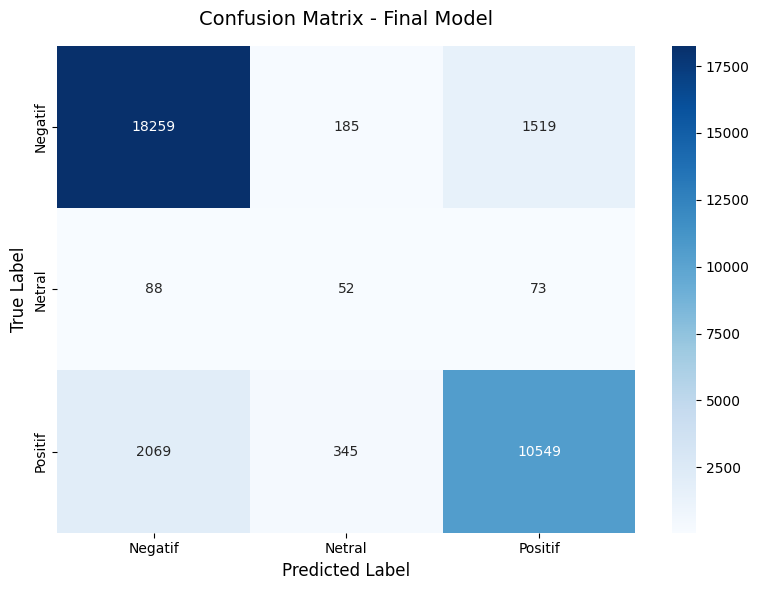

In [1]:
import pickle
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_existing_model():
    print("▶️ Memuat data uji dan model yang sudah dilatih...")

    # 1. Load Data Uji
    try:
        with open("final_data_for_model.pkl", 'rb') as f:
            data = pickle.load(f)
        X_test = data['X_test_original']
        y_test = data['y_test_original']
        print("✅ Data uji berhasil dimuat.")
    except FileNotFoundError:
        print("❌ File 'final_data_for_model.pkl' tidak ditemukan!")
        return

    # 2. Load Model yang sudah dilatih
    try:
        model = joblib.load("model_random_forest_final.joblib")
        print("✅ Model berhasil dimuat.")
    except FileNotFoundError:
        print("❌ File 'model_random_forest_final.joblib' tidak ditemukan!")
        return

    # 3. Lakukan Prediksi (Tanpa melatih ulang)
    print("\n🔬 Melakukan prediksi pada data uji...")
    y_pred = model.predict(X_test)

    # 4. Tampilkan Classification Report
    print("\n" + "="*50)
    print("📊 CLASSIFICATION REPORT")
    print("="*50)
    print(classification_report(y_test, y_pred))

    # 5. Buat dan Tampilkan Visualisasi Confusion Matrix
    print("\n📈 Membuat plot Confusion Matrix...")
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=model.classes_, 
                yticklabels=model.classes_)
    
    plt.title('Confusion Matrix - Final Model', fontsize=14, pad=15)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    
    # Menyimpan gambar confusion matrix (opsional)
    plt.savefig('confusion_matrix_plot.png')
    print("✅ Gambar confusion matrix disimpan sebagai 'confusion_matrix_plot.png'")
    
    # Menampilkan plot di layar
    plt.show()

if __name__ == "__main__":
    evaluate_existing_model()